suicides


In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
couse_of_suicid = pd.read_csv("Cause-wise Distribution_2021.csv")
personal_status_summary = pd.read_csv("Cause-wise Distribution_economic_status_2021.csv" , encoding='cp1252')
couse_of_death = pd.read_csv("Cause-wise Distribution_mode_2021.csv")

clean personal status

In [3]:
print(couse_of_suicid.info())
print(personal_status_summary.info())
print(couse_of_death.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 22 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Sl.No                                      26 non-null     object
 1   Cause                                      26 non-null     object
 2   Below 18 years - Male                      26 non-null     int64 
 3   Below 18 years - Female                    26 non-null     int64 
 4   Below 18 years - Transgender               26 non-null     int64 
 5   Below 18 years - Total                     26 non-null     int64 
 6   18 and Above-Below 30 years - Male         26 non-null     int64 
 7   18 and Above-Below 30 years - Female       26 non-null     int64 
 8   18 and Above-Below 30 years - Transgender  26 non-null     int64 
 9   18 and Above-Below 30 years - Total        26 non-null     int64 
 10  30 and Above-Below 45 years - Male      

In [4]:
print(personal_status_summary.head())
print(personal_status_summary.tail())
print(personal_status_summary.sample())
personal_status_summary.drop("Transgender" ,axis = 1, inplace=True)
personal_status_summary["Total"] = personal_status_summary["Male"] + personal_status_summary["Female"]
personal_status_summary.head()


         Category            Status   Male  Female  Transgender
0  Marital Status        Un-Married  27305   12096           20
1  Marital Status           Married  81063   28680            6
2  Marital Status  Widowed/ Widower   1470    1015            0
3  Marital Status          Divorcee    494     294            0
4  Marital Status         Separated    626     243            2
              Category                                             Status  \
15  Educational Status  Hr. Secondary/ Intermediate/ Pre-University (u...   
16  Educational Status                          Diploma/ Certificate/ ITI   
17  Educational Status                                 Graduate and above   
18  Educational Status                           Professionals (MBA etc.)   
19  Educational Status                                   Status Not Known   

     Male  Female  Transgender  
15  19479    7011            2  
16   1654     334            0  
17   5542    2070            1  
18    376     161    

,Category,Status,Male,Female,Total
0,Marital Status,Un-Married,27305,12096,39401
1,Marital Status,Married,81063,28680,109743
2,Marital Status,Widowed/ Widower,1470,1015,2485
3,Marital Status,Divorcee,494,294,788
4,Marital Status,Separated,626,243,869


visualization

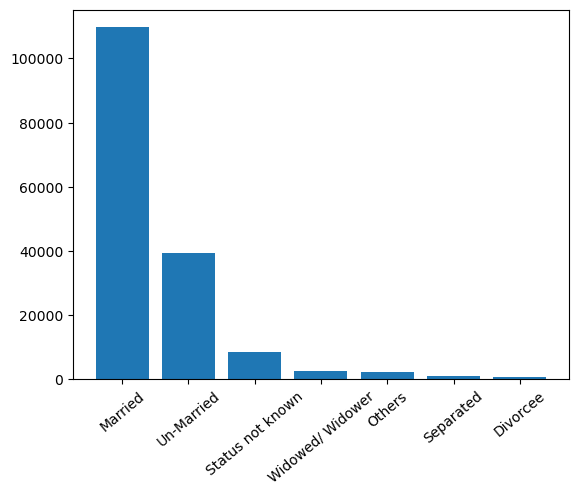

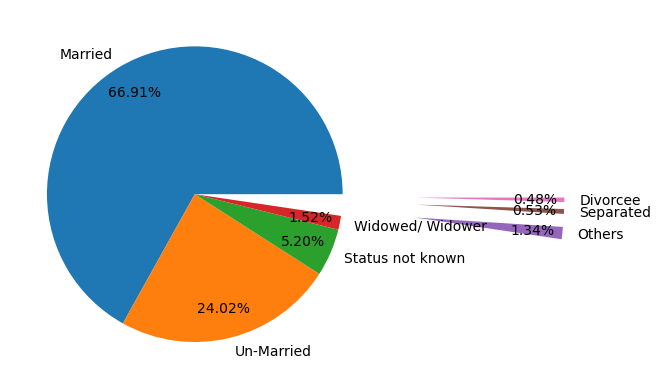

In [5]:
marital_st = personal_status_summary[personal_status_summary["Category"] == "Marital Status"].sort_values("Total" , ascending = False)

plt.bar(marital_st["Status"] , marital_st["Total"] )
plt.xticks(rotation = 40)
plt.show()
plt.pie(marital_st["Total"] , labels=marital_st["Status"] , autopct="%.2f%%" ,explode=[0 ,0,0,0,1.5,1.5,1.5] , pctdistance=0.8)
plt.show()

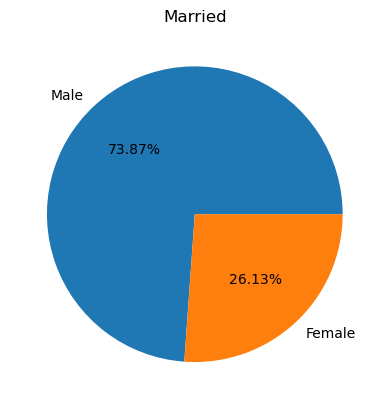

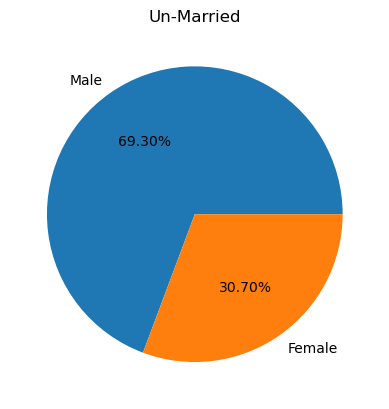

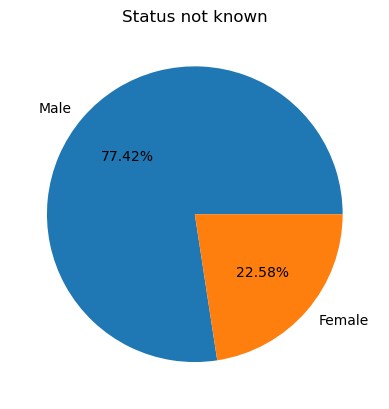

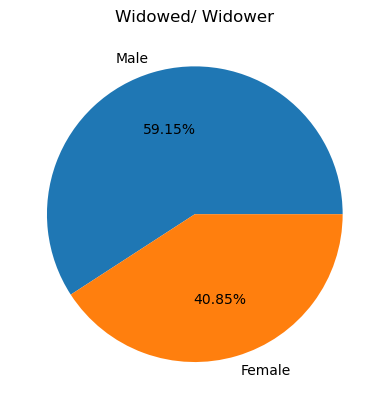

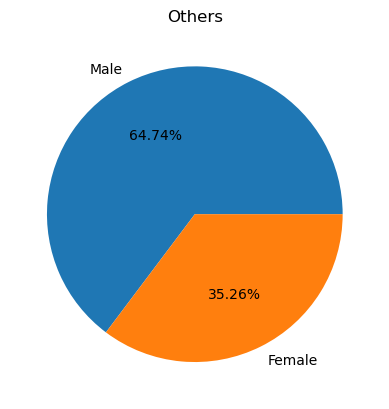

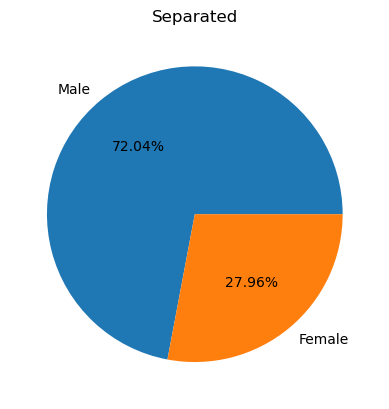

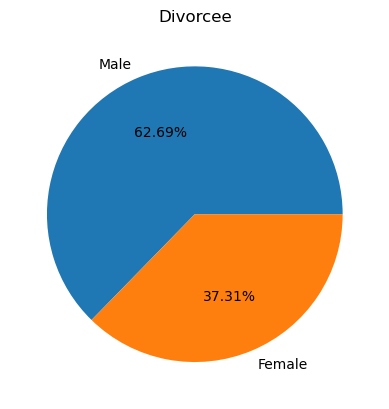

In [6]:
for i in marital_st["Status"]:
    x = marital_st[marital_st["Status"] == i].reset_index()
    plt.pie([x["Male"][0] , x["Female"][0]] , labels=["Male" , "Female"] , autopct="%.2f%%")
    plt.title(i)
    plt.show()

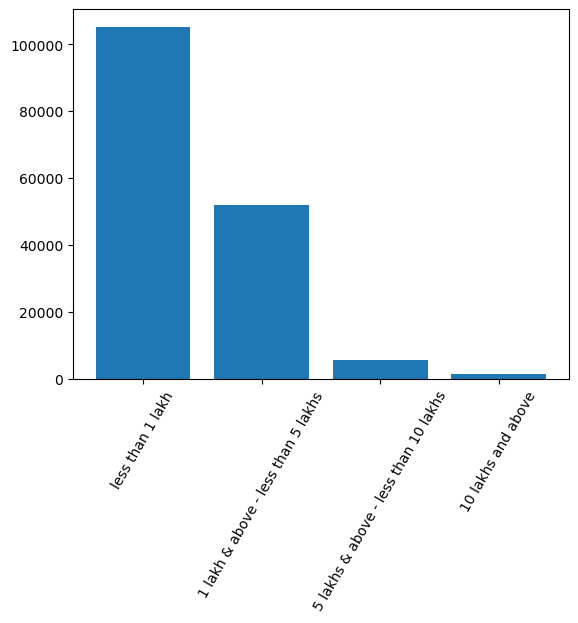

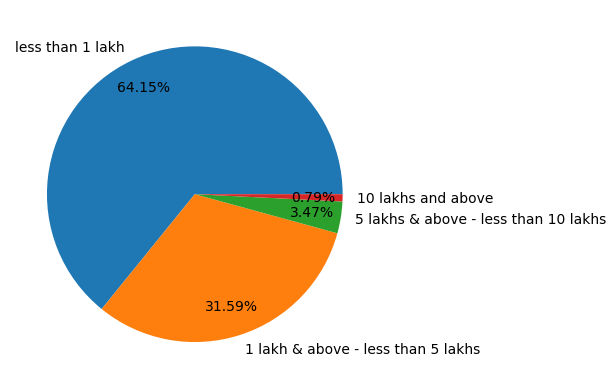

In [7]:

economicl_st = personal_status_summary[personal_status_summary["Category"] == "Economic Status"]

plt.bar(economicl_st["Status"] , economicl_st["Total"] )
plt.xticks(rotation = 60)
plt.show()
plt.pie(economicl_st["Total"] , labels=economicl_st["Status"] , autopct="%.2f%%"  , pctdistance=0.8)
plt.show()

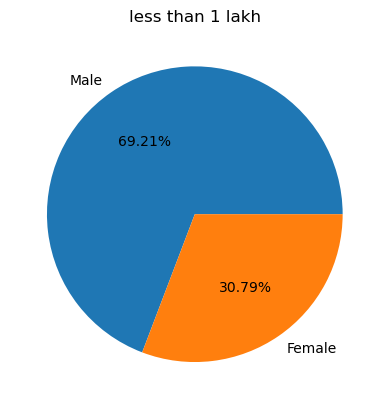

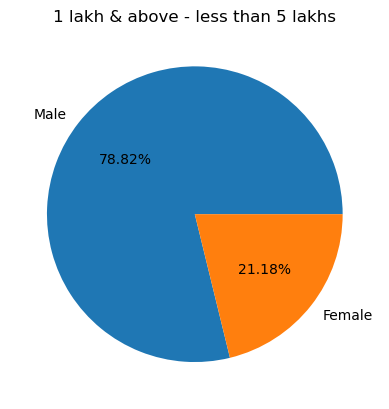

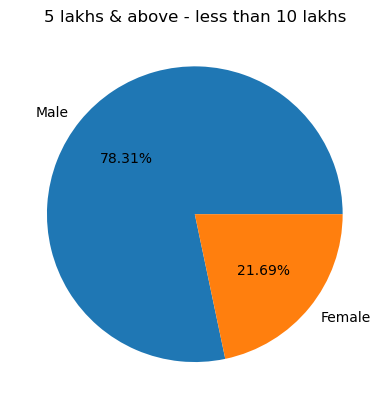

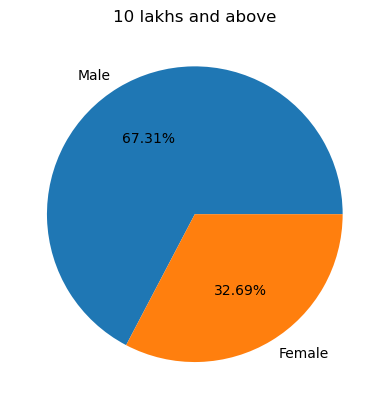

In [8]:
for i in economicl_st["Status"]:
    x = economicl_st[economicl_st["Status"] == i].reset_index()
    plt.pie([x["Male"][0] , x["Female"][0]] , labels=["Male" , "Female"] , autopct="%.2f%%")
    plt.title(i)
    plt.show()

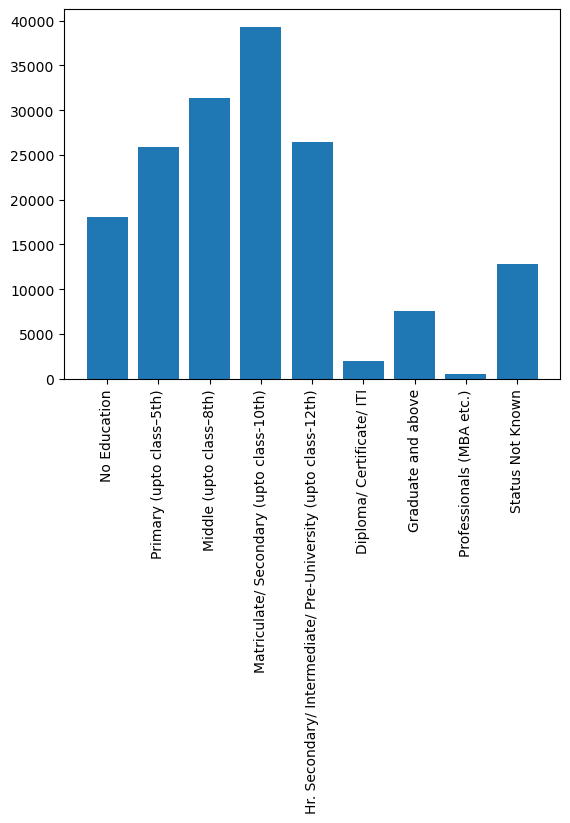

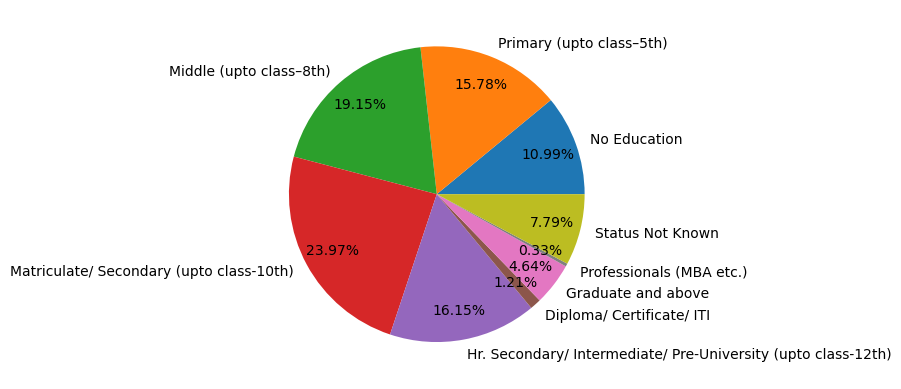

In [9]:
educational_st = personal_status_summary[personal_status_summary["Category"] == "Educational Status"]

plt.bar(educational_st["Status"] , educational_st["Total"] )
plt.xticks(rotation = 90)
plt.show()
plt.pie(educational_st["Total"] , labels=educational_st["Status"] , autopct="%.2f%%"  , pctdistance=0.8)
plt.show()

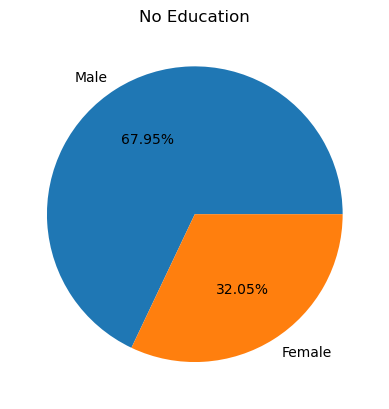

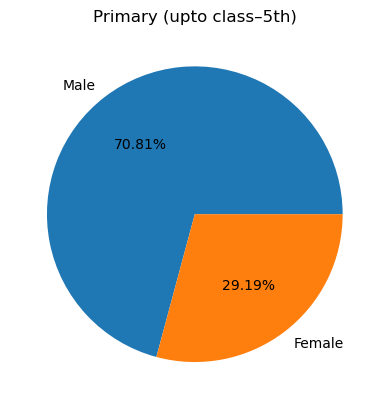

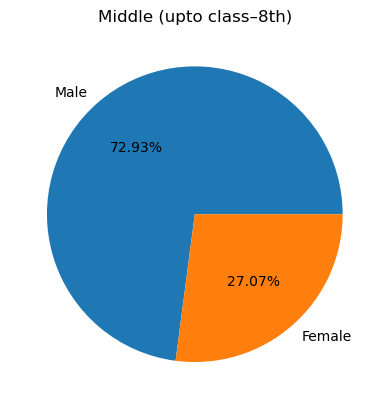

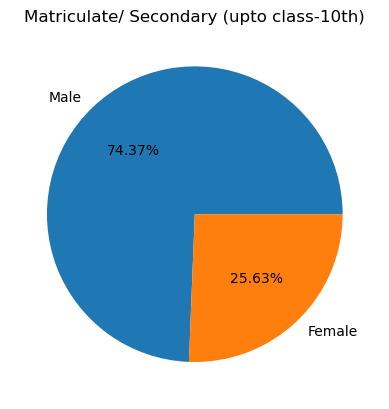

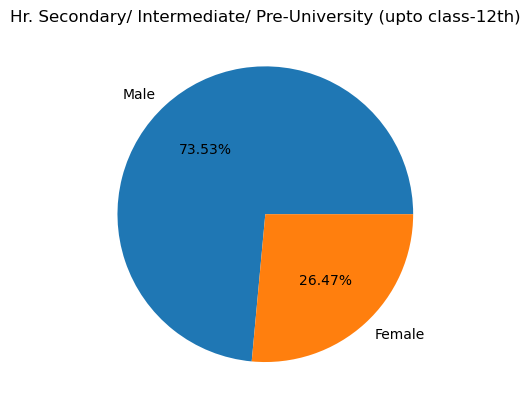

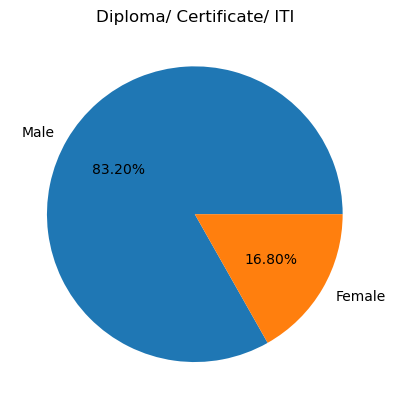

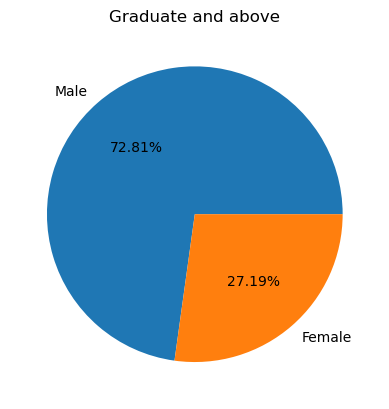

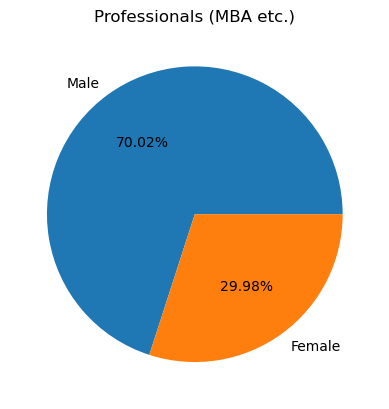

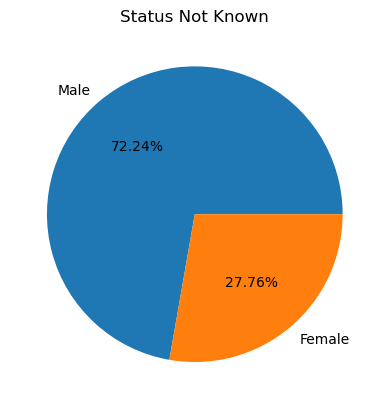

In [10]:
for i in educational_st["Status"]:
    x = educational_st[educational_st["Status"] == i].reset_index()
    plt.pie([x["Male"][0] , x["Female"][0]] , labels=["Male" , "Female"] , autopct="%.2f%%")
    plt.title(i)
    plt.show()

In [11]:
couse_of_death.head(5)
couse_of_death_clean = couse_of_death.copy()
couse_of_death_clean.drop("Transgender" ,axis = 1, inplace=True)
couse_of_death_clean.drop_duplicates(subset = ["Sl. No."] , keep="first" , inplace=True)
couse_of_death_clean["Total"] = couse_of_death_clean["Male"] + couse_of_death_clean["Female"]
couse_of_death_clean =couse_of_death_clean.sort_values("Total" , ascending = False)
couse_of_death_clean

,Sl. No.,Cause,Male,Female,Total
4,5,By Hanging,69917,23646,93563
5,6,By Poison (Total),29408,11784,41192
15,11,By Other Means,5728,2989,8717
1,2,By Drowning,5758,2611,8369
2,3,By Fire/Self Immolation,1757,2435,4192
13,9,By Coming under Running Vehicles/Trains,3476,497,3973
9,8,Jumping (Total),1338,419,1757
0,1,By Consuming Sleeping Pills,484,253,737
14,10,By Touching Electric Wire,464,163,627
8,7,By Self inflicting Injury,348,144,492


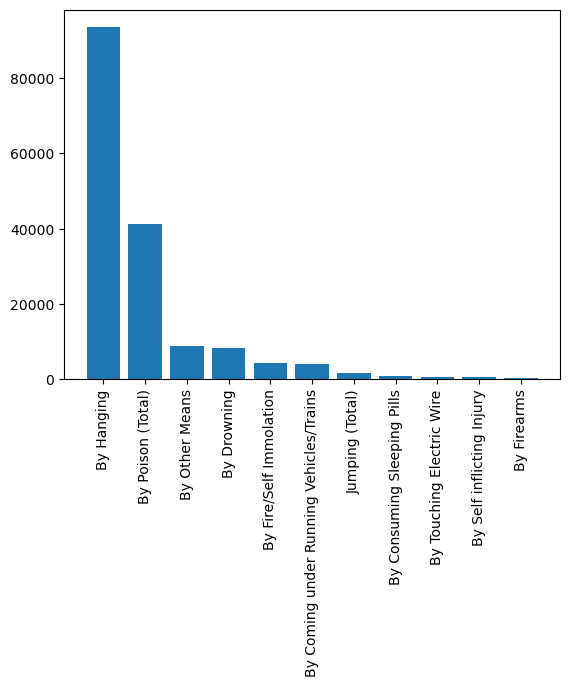

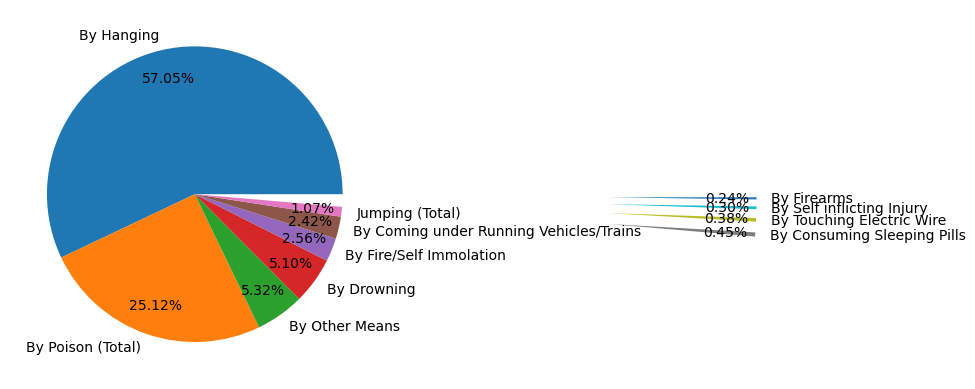

In [12]:
plt.bar(couse_of_death_clean["Cause"] , couse_of_death_clean["Total"])
plt.xticks(rotation = 90)
plt.show()
plt.pie(couse_of_death_clean["Total"] , labels=couse_of_death_clean["Cause"] , autopct="%.2f%%"  , pctdistance=0.8 , explode=[0 ,0,0,0,0,0,0,2.8,2.8,2.8,2.8])
plt.show()

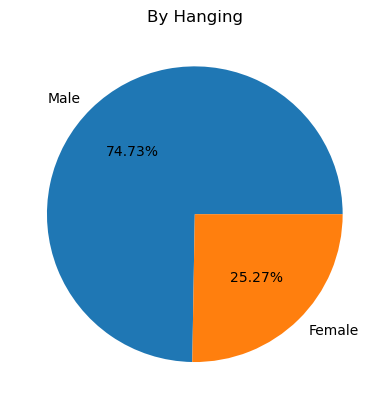

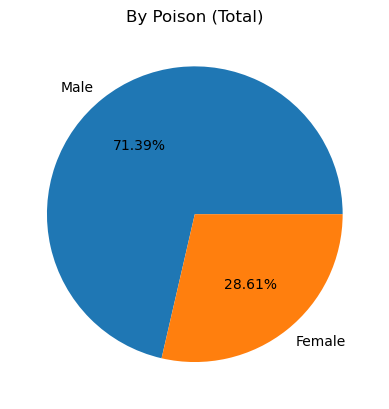

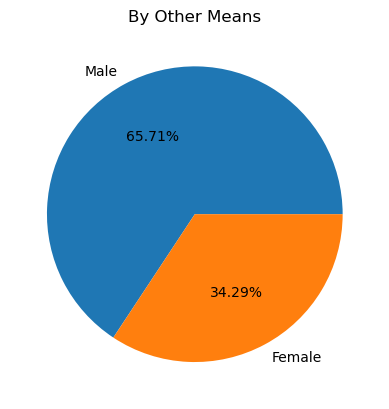

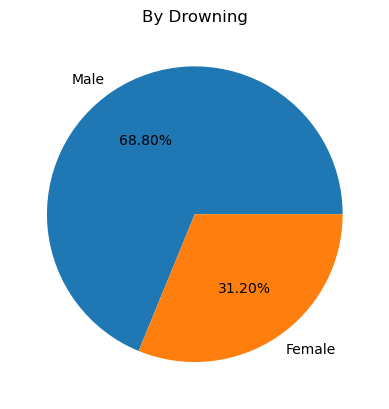

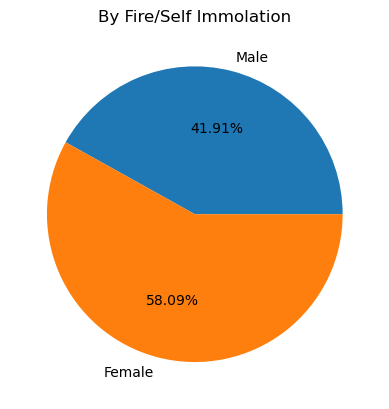

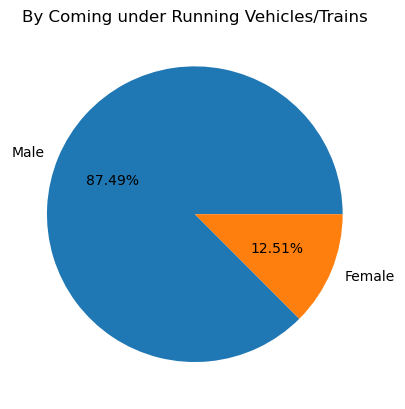

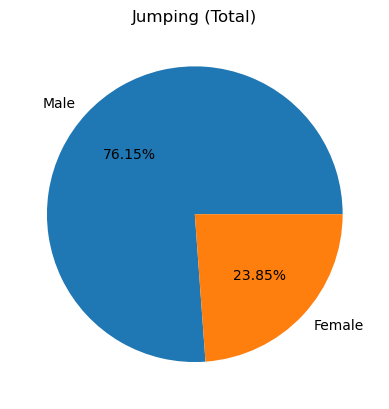

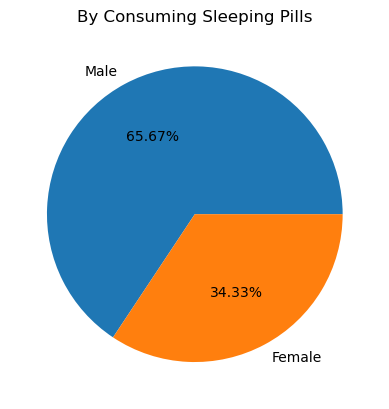

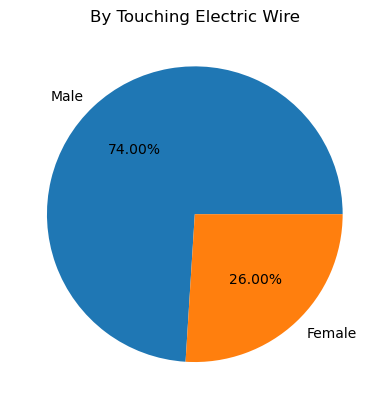

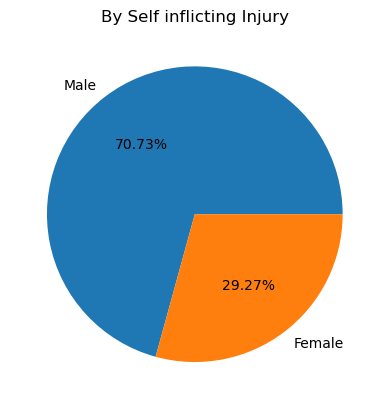

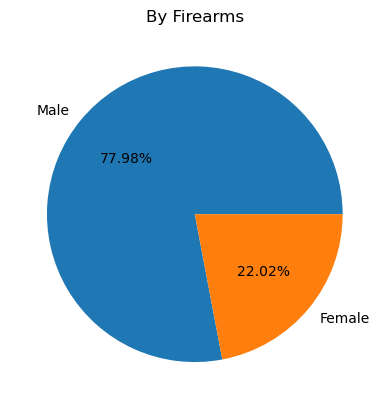

In [13]:
for i in couse_of_death_clean["Cause"]:
    x = couse_of_death_clean[couse_of_death_clean["Cause"] == i].reset_index()
    plt.pie([x["Male"][0] , x["Female"][0]] , labels=["Male" , "Female"] , autopct="%.2f%%")
    plt.title(i)
    plt.show()

In [14]:
couse_of_suicid_clean = couse_of_suicid.copy()
couse_of_suicid_clean.drop(["Below 18 years - Transgender" , "18 and Above-Below 30 years - Transgender","30 and Above-Below 45 years - Transgender" , "45 and Above-Below 60 years - Transgender" , "60 years & Above - Transgender"] ,axis = 1, inplace=True)

  Sl.No                       Cause  Below 18 years - Male  \
0     1  Bankruptcy or Indebtedness                     16   

   Below 18 years - Female  Below 18 years - Total  \
0                       10                      26   

   18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
0                                1100                                   125   

   18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
0                                 1225                                2517   

   30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
0                                   210                                 2727   

   45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
0                                1820                                   108   

   45 and Above-Below 60 years - Total  60 years & Above - Male  \
0                                 1928                      426

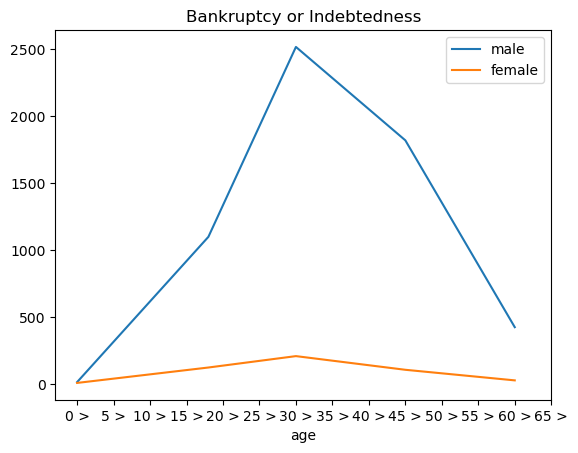

  Sl.No                            Cause  Below 18 years - Male  \
1     2  Marriage Related Issues (Total)                     68   

   Below 18 years - Female  Below 18 years - Total  \
1                      126                     194   

   18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
1                                1772                                  2631   

   18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
1                                 4404                                1581   

   30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
1                                  1153                                 2734   

   45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
1                                 351                                   149   

   45 and Above-Below 60 years - Total  60 years & Above - Male  \
1                                  500               

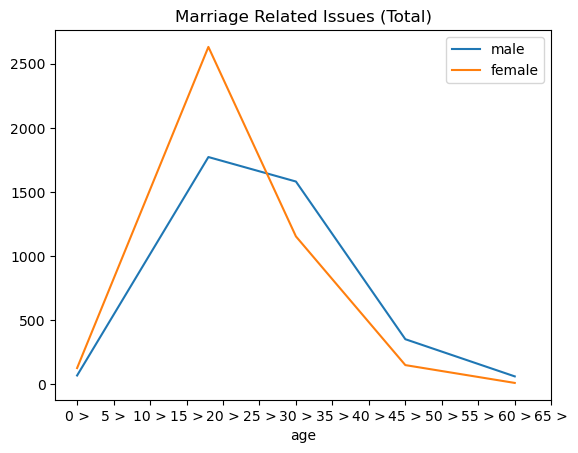

  Sl.No                   Cause  Below 18 years - Male  \
2     3  Failure in Examination                    467   

   Below 18 years - Female  Below 18 years - Total  \
2                      397                     864   

   18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
2                                 449                                   265   

   18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
2                                  714                                  56   

   30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
2                                    16                                   72   

   45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
2                                  17                                     3   

   45 and Above-Below 60 years - Total  60 years & Above - Male  \
2                                   20                        2   

   

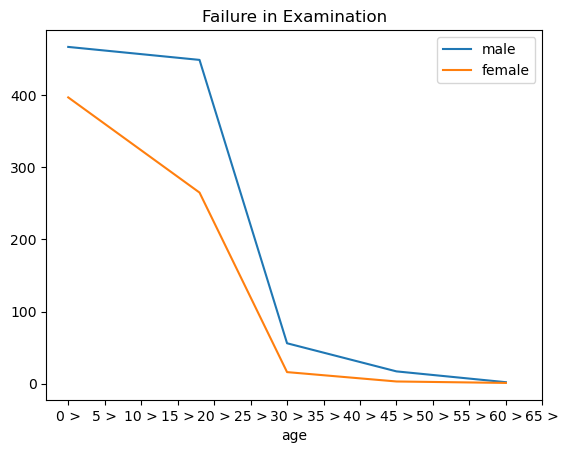

  Sl.No                  Cause  Below 18 years - Male  \
3     4  Impotency/Infertility                      0   

   Below 18 years - Female  Below 18 years - Total  \
3                       13                      13   

   18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
3                                  43                                   102   

   18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
3                                  145                                  95   

   30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
3                                    81                                  176   

   45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
3                                  38                                    22   

   45 and Above-Below 60 years - Total  60 years & Above - Male  \
3                                   60                        9   

   60

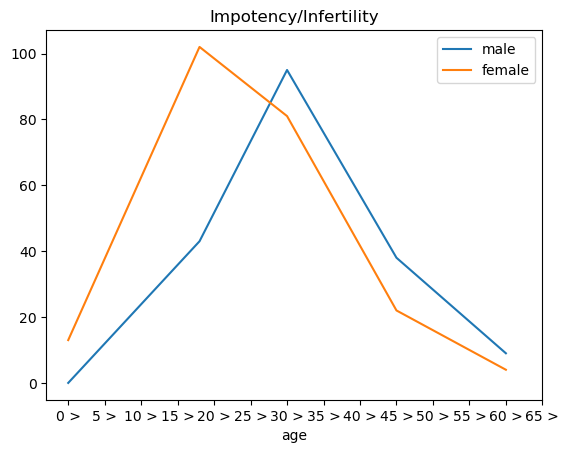

  Sl.No            Cause  Below 18 years - Male  Below 18 years - Female  \
4     5  Family Problems                   1630                     1603   

   Below 18 years - Total  18 and Above-Below 30 years - Male  \
4                    3233                               12345   

   18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
4                                  6786                                19134   

   30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
4                               13764                                  4515   

   30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
4                                18283                                7687   

   45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
4                                  1926                                 9613   

   60 years & Above - Male  60 years & Above - Female  \
4                    

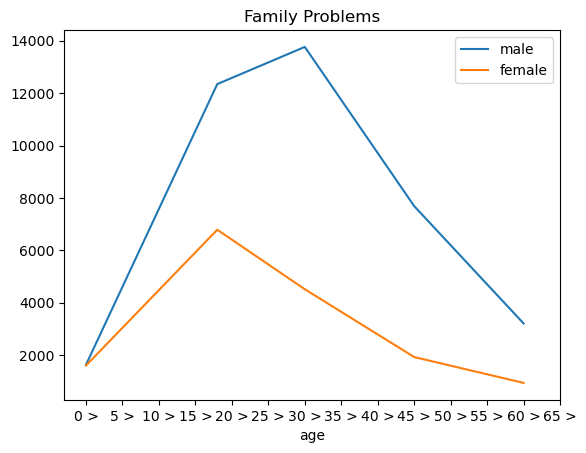

  Sl.No            Cause  Below 18 years - Male  Below 18 years - Female  \
5     6  Illness (Total)                    596                      812   

   Below 18 years - Total  18 and Above-Below 30 years - Male  \
5                    1408                                4973   

   18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
5                                  2537                                 7513   

   30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
5                                5955                                  2436   

   30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
5                                 8393                                5410   

   45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
5                                  1855                                 7266   

   60 years & Above - Male  60 years & Above - Female  \
5                    

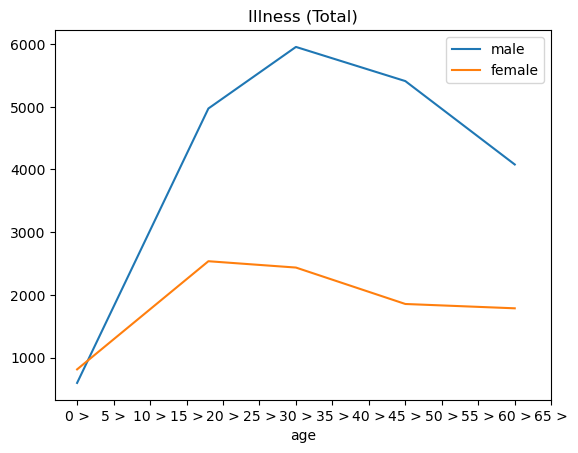

  Sl.No         Cause  Below 18 years - Male  Below 18 years - Female  \
6     6  6.1 AIDS/STD                      4                        1   

   Below 18 years - Total  18 and Above-Below 30 years - Male  \
6                       5                                  14   

   18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
6                                     9                                   23   

   30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
6                                  41                                     7   

   30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
6                                   48                                  29   

   45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
6                                     9                                   39   

   60 years & Above - Male  60 years & Above - Female  \
6                       10 

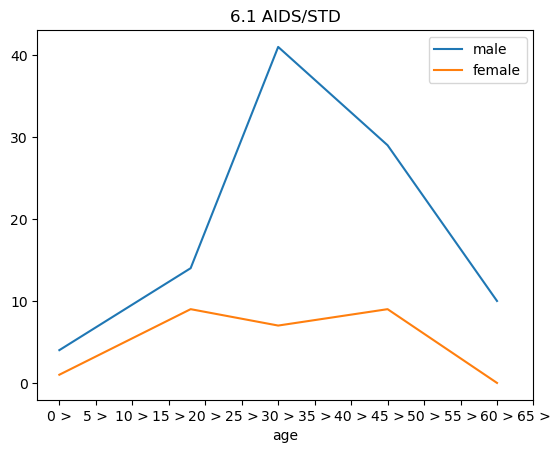

  Sl.No       Cause  Below 18 years - Male  Below 18 years - Female  \
7     6  6.2 Cancer                      4                       10   

   Below 18 years - Total  18 and Above-Below 30 years - Male  \
7                      14                                  84   

   18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
7                                    28                                  112   

   30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
7                                 257                                    71   

   30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
7                                  328                                 304   

   45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
7                                   115                                  419   

   60 years & Above - Male  60 years & Above - Female  \
7                      260     

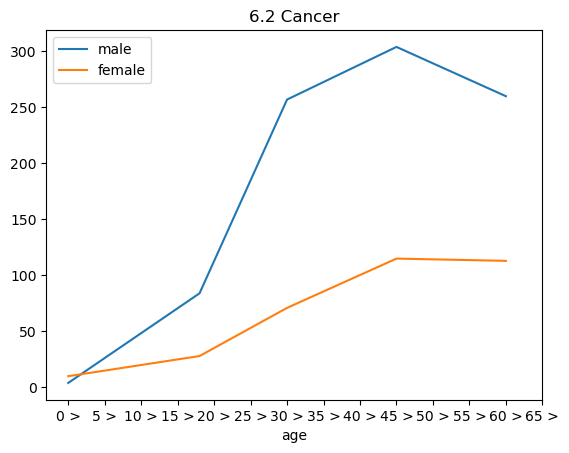

  Sl.No          Cause  Below 18 years - Male  Below 18 years - Female  \
8     6  6.3 Paralysis                      4                        6   

   Below 18 years - Total  18 and Above-Below 30 years - Male  \
8                      10                                  82   

   18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
8                                    23                                  105   

   30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
8                                 214                                    63   

   30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
8                                  277                                 326   

   45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
8                                    77                                  403   

   60 years & Above - Male  60 years & Above - Female  \
8                      30

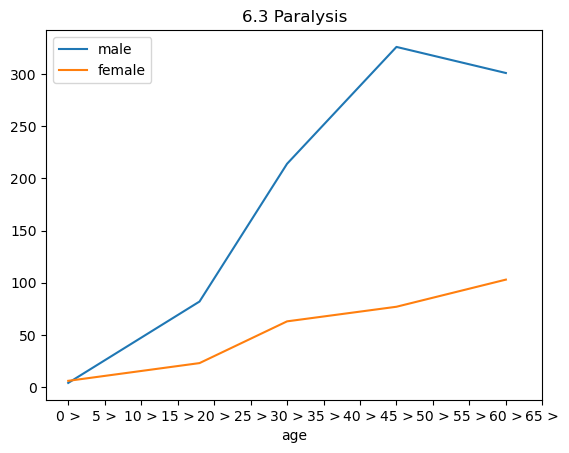

  Sl.No                         Cause  Below 18 years - Male  \
9     6  6.4 Insanity/ Mental Illness                    412   

   Below 18 years - Female  Below 18 years - Total  \
9                      410                     822   

   18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
9                                3015                                  1275   

   18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
9                                 4291                                3119   

   30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
9                                  1099                                 4219   

   45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
9                                2011                                   714   

   45 and Above-Below 60 years - Total  60 years & Above - Male  \
9                                 2725                     

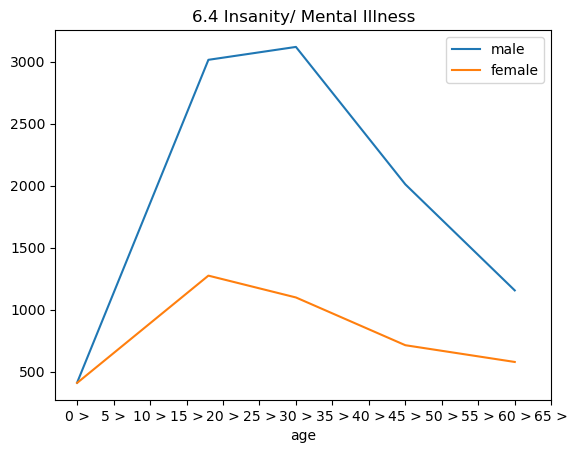

   Sl.No                        Cause  Below 18 years - Male  \
10     6  6.5 Other Prolonged Illness                    172   

    Below 18 years - Female  Below 18 years - Total  \
10                      385                     557   

    18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
10                                1778                                  1202   

    18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
10                                 2982                                2324   

    30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
10                                  1196                                 3521   

    45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
10                                2740                                   940   

    45 and Above-Below 60 years - Total  60 years & Above - Male  \
10                                 3680         

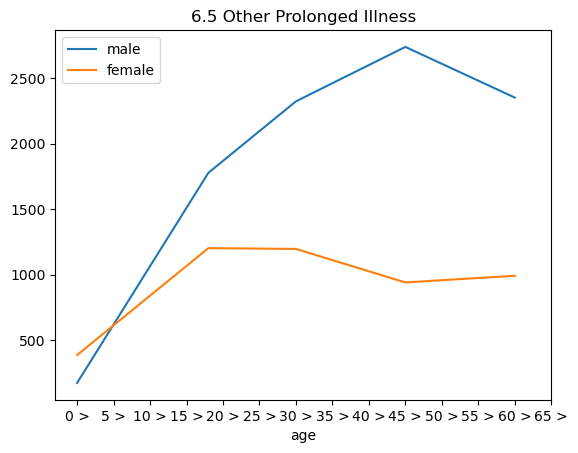

   Sl.No                 Cause  Below 18 years - Male  \
11     7  Death of Dear Person                     38   

    Below 18 years - Female  Below 18 years - Total  \
11                       42                      80   

    18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
11                                 352                                   180   

    18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
11                                  532                                 374   

    30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
11                                   193                                  567   

    45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
11                                 305                                   127   

    45 and Above-Below 60 years - Total  60 years & Above - Male  \
11                                  432                      2

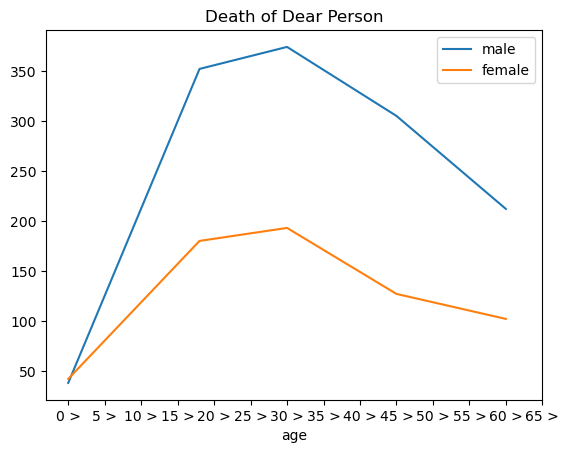

   Sl.No                           Cause  Below 18 years - Male  \
12     8  Drug Abuse/Alcoholic Addiction                     83   

    Below 18 years - Female  Below 18 years - Total  \
12                       33                     116   

    18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
12                                2774                                    78   

    18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
12                                 2852                                4138   

    30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
12                                    87                                 4226   

    45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
12                                2525                                    59   

    45 and Above-Below 60 years - Total  60 years & Above - Male  \
12                                 2584   

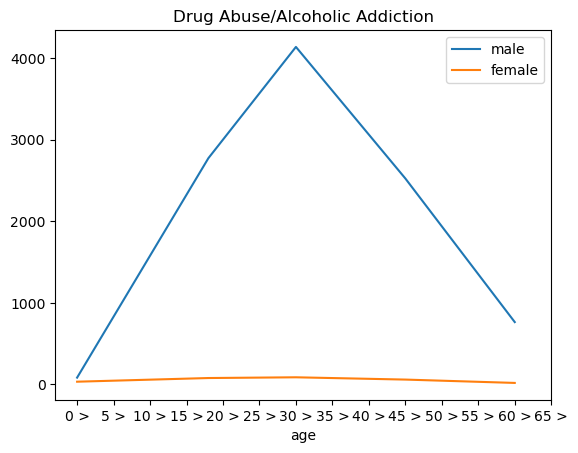

   Sl.No                      Cause  Below 18 years - Male  \
13     9  Fall in Social Reputation                     37   

    Below 18 years - Female  Below 18 years - Total  \
13                       23                      60   

    18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
13                                 214                                    52   

    18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
13                                  266                                 230   

    30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
13                                    40                                  270   

    45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
13                                 157                                    28   

    45 and Above-Below 60 years - Total  60 years & Above - Male  \
13                                  185             

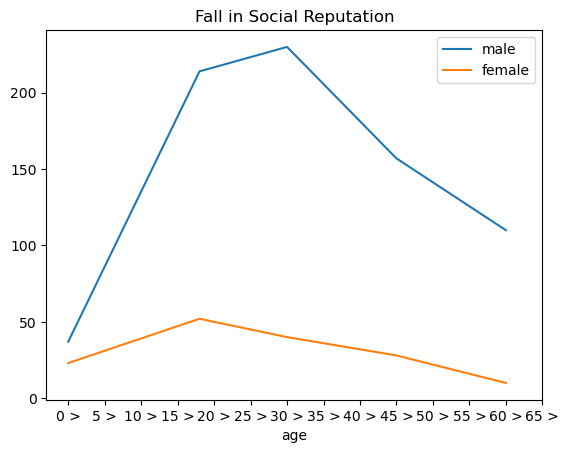

   Sl.No                                Cause  Below 18 years - Male  \
14    10  Ideological Causes/Hero Worshipping                     10   

    Below 18 years - Female  Below 18 years - Total  \
14                        9                      19   

    18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
14                                  43                                    22   

    18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
14                                   65                                  33   

    30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
14                                     8                                   41   

    45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
14                                  24                                     2   

    45 and Above-Below 60 years - Total  60 years & Above - Male  \
14                              

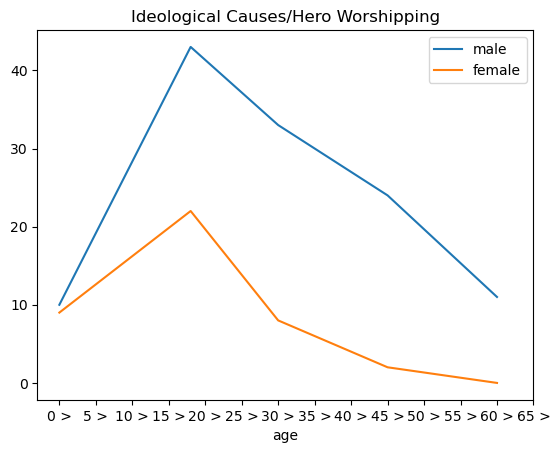

   Sl.No         Cause  Below 18 years - Male  Below 18 years - Female  \
15    11  Love Affairs                    585                      910   

    Below 18 years - Total  18 and Above-Below 30 years - Male  \
15                    1495                                3167   

    18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
15                                  1652                                 4821   

    30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
15                                 817                                   314   

    30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
15                                 1131                                  92   

    45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
15                                    18                                  110   

    60 years & Above - Male  60 years & Above - Female  \
15            

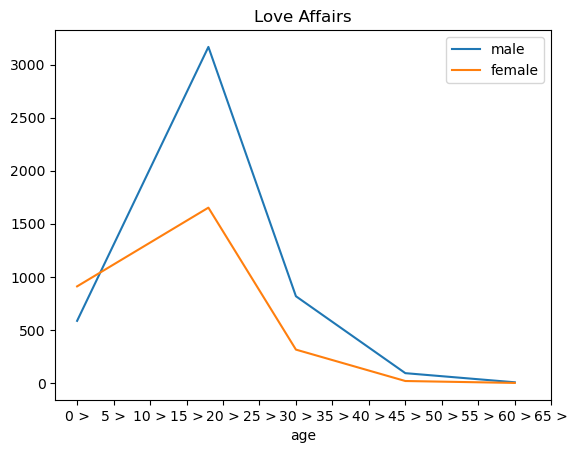

   Sl.No    Cause  Below 18 years - Male  Below 18 years - Female  \
16    12  Poverty                     43                       26   

    Below 18 years - Total  18 and Above-Below 30 years - Male  \
16                      69                                 372   

    18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
16                                    81                                  453   

    30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
16                                 590                                    74   

    30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
16                                  664                                 444   

    45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
16                                    43                                  487   

    60 years & Above - Male  60 years & Above - Female  \
16                      

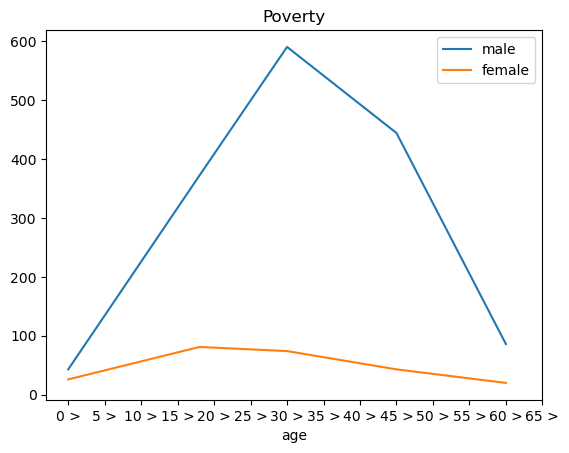

   Sl.No         Cause  Below 18 years - Male  Below 18 years - Female  \
17    13  Unemployment                     55                       28   

    Below 18 years - Total  18 and Above-Below 30 years - Male  \
17                      83                                1316   

    18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
17                                   157                                 1474   

    30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
17                                1264                                    99   

    30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
17                                 1363                                 484   

    45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
17                                    35                                  519   

    60 years & Above - Male  60 years & Above - Female  \
17            

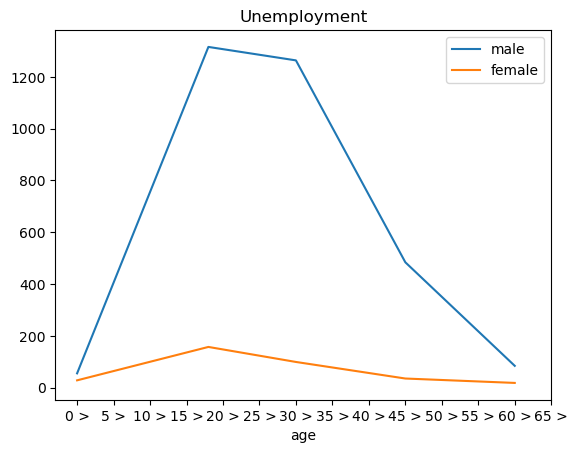

   Sl.No             Cause  Below 18 years - Male  Below 18 years - Female  \
18    14  Property Dispute                     38                       31   

    Below 18 years - Total  18 and Above-Below 30 years - Male  \
18                      69                                 425   

    18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
18                                   103                                  528   

    30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
18                                 528                                   113   

    30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
18                                  641                                 421   

    45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
18                                    75                                  496   

    60 years & Above - Male  60 years & Above - Female  \
18    

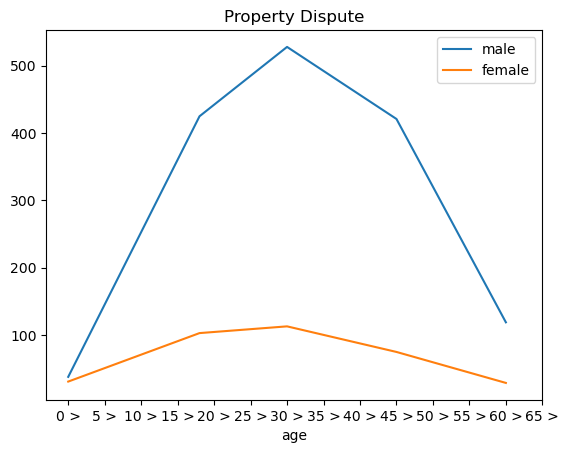

   Sl.No                                              Cause  \
19    15  Suspected/ Illicit Relation (Other than Sl. No...   

    Below 18 years - Male  Below 18 years - Female  Below 18 years - Total  \
19                     13                       22                      35   

    18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
19                                 170                                   143   

    18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
19                                  313                                 161   

    30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
19                                    96                                  257   

    45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
19                                  69                                    16   

    45 and Above-Below 60 years - Total  60 years & Above - Male  \
19  

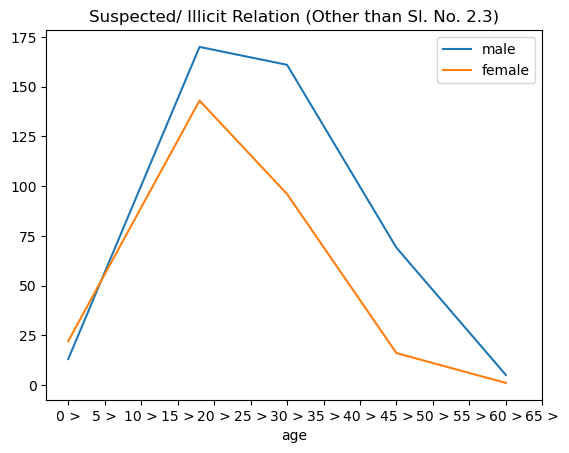

   Sl.No                                           Cause  \
20    16  Illegitimate Pregnancy (Other thanSl. No. 2.3)   

    Below 18 years - Male  Below 18 years - Female  Below 18 years - Total  \
20                      0                        7                       7   

    18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
20                                   0                                    31   

    18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
20                                   31                                   0   

    30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
20                                    12                                   12   

    45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
20                                   0                                     0   

    45 and Above-Below 60 years - Total  60 years & Above - Male  \
20        

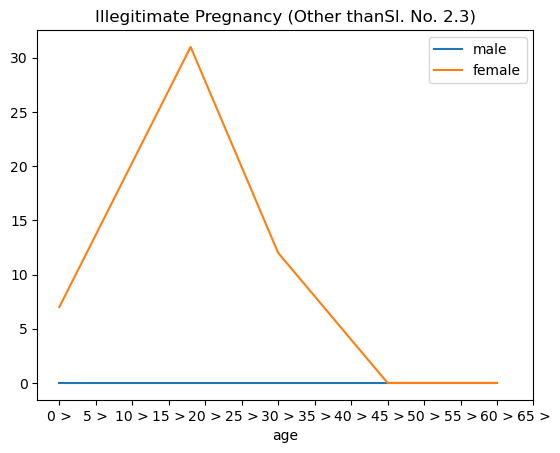

   Sl.No                        Cause  Below 18 years - Male  \
21    17  Physical Abuse (Rape, etc.)                      6   

    Below 18 years - Female  Below 18 years - Total  \
21                       26                      32   

    18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
21                                   5                                    19   

    18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
21                                   24                                   8   

    30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
21                                     7                                   15   

    45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
21                                   6                                     1   

    45 and Above-Below 60 years - Total  60 years & Above - Male  \
21                                    7         

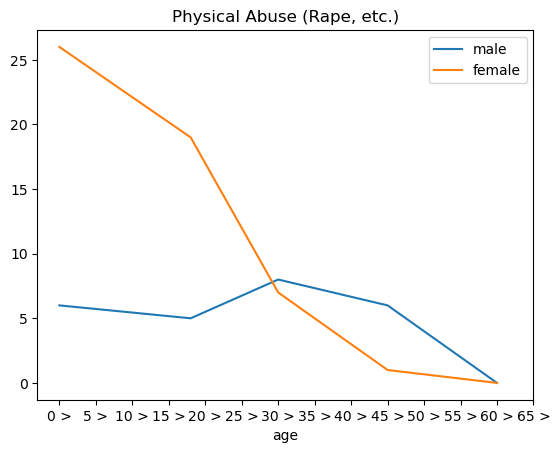

   Sl.No                        Cause  Below 18 years - Male  \
22    18  Professional/Career Problem                     58   

    Below 18 years - Female  Below 18 years - Total  \
22                       47                     105   

    18 and Above-Below 30 years - Male  18 and Above-Below 30 years - Female  \
22                                 786                                   197   

    18 and Above-Below 30 years - Total  30 and Above-Below 45 years - Male  \
22                                  983                                 809   

    30 and Above-Below 45 years - Female  30 and Above-Below 45 years - Total  \
22                                   103                                  912   

    45 and Above-Below 60 years - Male  45 and Above-Below 60 years - Female  \
22                                 401                                    61   

    45 and Above-Below 60 years - Total  60 years & Above - Male  \
22                                  462         

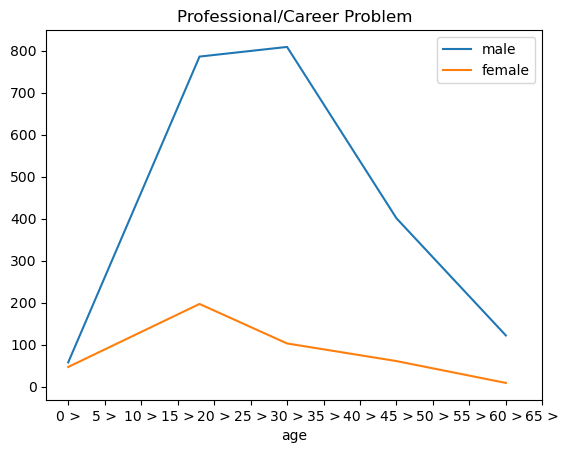

   Sl.No             Cause  Below 18 years - Male  Below 18 years - Female  \
23    19  Causes Not Known                    672                      664   

    Below 18 years - Total  18 and Above-Below 30 years - Male  \
23                    1336                                4138   

    18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
23                                  1812                                 5952   

    30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
23                                4068                                  1069   

    30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
23                                 5138                                2102   

    45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
23                                   487                                 2589   

    60 years & Above - Male  60 years & Above - Female  \
23    

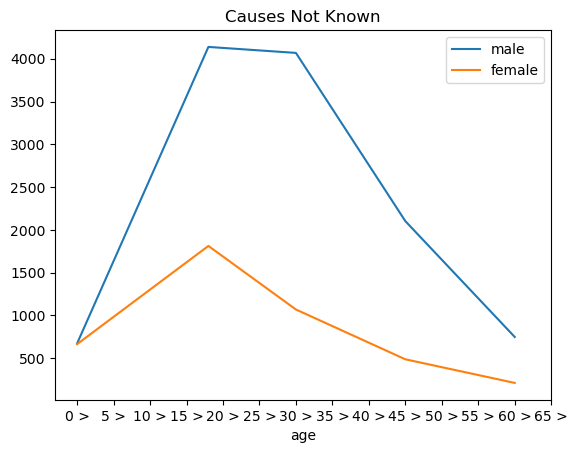

   Sl.No         Cause  Below 18 years - Male  Below 18 years - Female  \
24    20  Other Causes                    660                      826   

    Below 18 years - Total  18 and Above-Below 30 years - Male  \
24                    1488                                3497   

    18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
24                                  1615                                 5114   

    30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
24                                3427                                  1003   

    30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
24                                 4432                                2201   

    45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
24                                   592                                 2794   

    60 years & Above - Male  60 years & Above - Female  \
24            

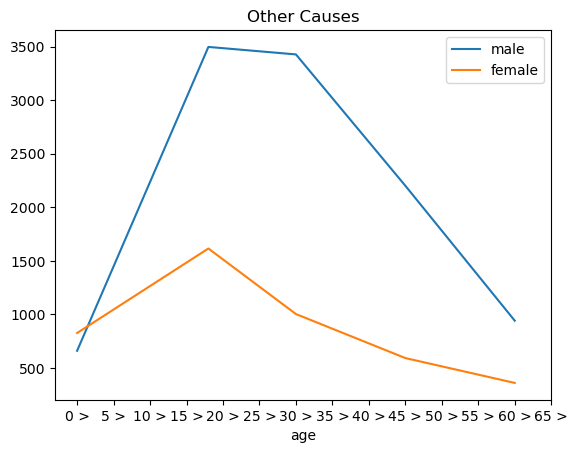

    Sl.No  Cause  Below 18 years - Male  Below 18 years - Female  \
25  Total  Total                   5075                     5655   

    Below 18 years - Total  18 and Above-Below 30 years - Male  \
25                   10732                               37941   

    18 and Above-Below 30 years - Female  18 and Above-Below 30 years - Total  \
25                                 18588                                56543   

    30 and Above-Below 45 years - Male  30 and Above-Below 45 years - Female  \
25                               40415                                 11629   

    30 and Above-Below 45 years - Total  45 and Above-Below 60 years - Male  \
25                                52054                               24554   

    45 and Above-Below 60 years - Female  45 and Above-Below 60 years - Total  \
25                                  5607                                30163   

    60 years & Above - Male  60 years & Above - Female  \
25                    1099

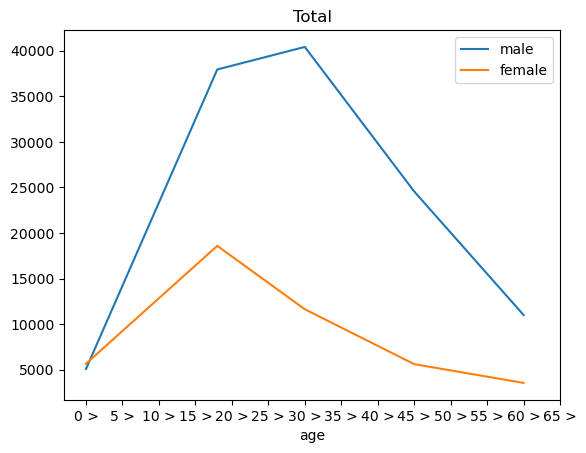

In [15]:

for z in couse_of_suicid_clean["Cause"]:
    x = couse_of_suicid_clean[couse_of_suicid_clean["Cause"] == z][["Below 18 years - Male" , "18 and Above-Below 30 years - Male","30 and Above-Below 45 years - Male" , "45 and Above-Below 60 years - Male" , "60 years & Above - Male"]]
    plt.plot([0 ,18,30,45,60] , list(x.iloc[0,:]))

    x = couse_of_suicid_clean[couse_of_suicid_clean["Cause"] == z][["Below 18 years - Female" , "18 and Above-Below 30 years - Female","30 and Above-Below 45 years - Female" , "45 and Above-Below 60 years - Female" , "60 years & Above - Female"]]
    plt.plot([0 ,18,30,45,60] , list(x.iloc[0,:]))

    print(couse_of_suicid_clean[couse_of_suicid_clean["Cause"] ==z])

    plt.title(z)
    plt.legend(["male","female"])
    test = list(range(0,70,5))
    plt.xticks(test ,[f"{x} >"for x in test])
    plt.xlabel("age")
    plt.show()
    list(x.iloc[0,:])

In [16]:
couse_of_suicid["Total"] = couse_of_suicid["Below 18 years - Total"] + couse_of_suicid["18 and Above-Below 30 years - Total"] + couse_of_suicid["30 and Above-Below 45 years - Total"] + couse_of_suicid["45 and Above-Below 60 years - Total"] + couse_of_suicid["60 years & Above - Total"] 

couse_of_suicid_summary = couse_of_suicid.copy()
couse_of_suicid_summary.drop([25,5] , axis = 0 ,inplace=True)


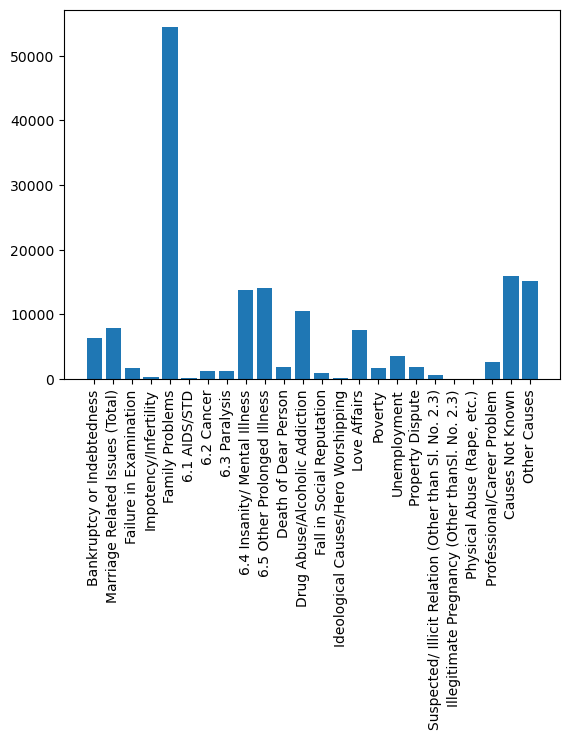

In [17]:
plt.bar(couse_of_suicid_summary["Cause"] , couse_of_suicid_summary["Total"])
plt.xticks(rotation = 90)
plt.show()
